# Initial data processing pipeline for ANTIPASTI input

In [2]:
import os
import torch
import matplotlib.pyplot as plt

from antipasti.preprocessing.preprocessing import Preprocessing
from antipasti.utils.torch_utils import create_test_set, save_checkpoint, load_checkpoint, training_routine

In [3]:
# Assign directories

# AF3 directories
AF_INPUT_PATH = '../af3/af_input/'
AF_OUTPUT_PATH = '../af3/af_output/'

# Structures directory
STRUCTURES_PATH = '../data/structures/'

# Data directories
DATA_PATH = '../data/'
RESIDUES_DIR = 'lists_of_residues/'
CHAIN_LENGTHS_DIR = 'chain_lengths/'
DCCM_MAPS_DIR = 'dccm_maps/'
TORCH_DIR = 'torch/'

# Original ANTIPASTI data directory
OLD_DATA_PATH = '../OLD/data/'

### Loading database

#### exploration

In [4]:
# SARS-CoV-2 spike ectodomain structure (open state)
s6vyb = "MGILPSPGMPALLSLVSLLSVLLMGCVAETGTQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCALDPLSETKCTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITPGTNTSNEVAVLYQDVNCTEVPVAIHADQLTPTWRVYSTGSNVFQTRAGCLIGAEHVNNSYECDIPIGAGICASYQTQTNSPSGAGSVASQSIIAYTMSLGAENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGIAVEQDKNTQEVFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDCLGDIAARDLICAQKFNGLTVLPPLLTDEMIAQYTSALLAGTITSGWTFGAGAALQIPFAMQMAYRFNGIGVTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVLNDILSRLDPPEAEVQIDRLITGRLQSLQTYVTQQLIRAAEIRASANLAATKMSECVLGQSKRVDFCGKGYHLMSFPQSAPHGVVFLHVTYVPAQEKNFTTAPAICHDGKAHFPREGVFVSNGTHWFVTQRNFYEPQIITTDNTFVSGNCDVVIGIVNNTVYDPLQPELDSFKEELDKYFKNHTSPDVDLGDISGINASVVNIQKEIDRLNEVAKNLNESLIDLQELGKYEQYIKGSGRENLYFQGGGGSGYIPEAPRDGQAYVRKDGEWVLLSTFLGHHHHHHHH"

# Structure of the SARS-CoV-2 spike glycoprotein (closed state)
s6vxx = "MGILPSPGMPALLSLVSLLSVLLMGCVAETGTQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCALDPLSETKCTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITPGTNTSNQVAVLYQDVNCTEVPVAIHADQLTPTWRVYSTGSNVFQTRAGCLIGAEHVNNSYECDIPIGAGICASYQTQTNSPSGAGSVASQSIIAYTMSLGAENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGIAVEQDKNTQEVFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDCLGDIAARDLICAQKFNGLTVLPPLLTDEMIAQYTSALLAGTITSGWTFGAGAALQIPFAMQMAYRFNGIGVTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVLNDILSRLDPPEAEVQIDRLITGRLQSLQTYVTQQLIRAAEIRASANLAATKMSECVLGQSKRVDFCGKGYHLMSFPQSAPHGVVFLHVTYVPAQEKNFTTAPAICHDGKAHFPREGVFVSNGTHWFVTQRNFYEPQIITTDNTFVSGNCDVVIGIVNNTVYDPLQPELDSFKEELDKYFKNHTSPDVDLGDISGINASVVNIQKEIDRLNEVAKNLNESLIDLQELGKYEQYIKGSGRENLYFQGGGGSGYIPEAPRDGQAYVRKDGEWVLLSTFLGHHHHHHHH"

# Structure of post fusion core of 2019-nCoV S2 subunit
s6lxt = "GVTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVLNDILSRLDKVESGGRGGPDVDLGDISGINASVVNIQKEIDRLNEVAKNLNESLIDLQELGKYGG"

In [5]:
print(len(s6vyb))
print(len(s6vxx))
print(len(s6lxt))


1281
1281
132


In [6]:
from antipasti.utils.biology_utils import antibody_sequence_identity
antibody_sequence_identity(s6vyb, s6vxx)

0.99921875

In [7]:
for idx, (a, b) in enumerate(zip(s6vyb, s6vxx)):
    if a != b:
        print(f"Index: {idx}, s6vyb: {a}, s6vxx: {b}")

Index: 625, s6vyb: E, s6vxx: Q


In [8]:
print(antibody_sequence_identity(s6lxt, s6vxx))
print(antibody_sequence_identity(s6lxt, s6vyb))

0.061068702290076333
0.061068702290076333


In [9]:
prot009 = "MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCALDPLSETKCTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITPGTNTSNQVAVLYQDVNCTEVPVAIHADQLTPTWRVYSTGSNVFQTRAGCLIGAEHVNNSYECDIPIGAGICASYQTQTNSPSGAGSVASQSIIAYTMSLGAENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGIAVEQDKNTQEVFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDCLGDIAARDLICAQKFNGLTVLPPLLTDEMIAQYTSALLAGTITSGWTFGAGAALQIPFAMQMAYRFNGIGVTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQIDRLITGRLQSLQTYVTQQLIRAAEIRASANLAATKMSECVLGQSKRVDFCGKGYHLMSFPQSAPHGVVFLHVTYVPAQEKNFTTAPAICHDGKAHFPREGVFVSNGTHWFVTQRNFYEPQIITTDNTFVSGNCDVVIGIVNNTVYDPLQPELDSFKEELDKYFKNHTSPDVDLGDISGINASVVNIQKEIDRLNEVAKNLNESLIDLQELGKYEQYIKWPWYIWLGFIAGLIAIVMVTIMLCCMTSCCSCLKGCSCGSCCKFDEDDSEPVLKGVKLHYYT"

In [10]:
print(antibody_sequence_identity(s6vyb, prot009))
print(antibody_sequence_identity(s6vxx, prot009))
print(antibody_sequence_identity(s6lxt, prot009))

0.05738993710691824
0.05738993710691824
0.06870229007633588


In [11]:
print(len(prot009))

1273


In [12]:
s_rbd = prot009[319-1:541]
print(len(s_rbd))
print(s_rbd)

223
RVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNF


In [13]:
indices = [i for i in range(len(s6vyb)) if s6vyb[i] != s6vxx[i]]
print(indices)

[625]


In [14]:
# Antigen sequences taken from antibody PDB structures

s7bz5 = "RVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFHHHHHH"
s7c01 = "RVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFHHHHHH"
s7bwj = "RVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKHHHHHH"

In [15]:
print(antibody_sequence_identity(s_rbd, s7bz5))
print(antibody_sequence_identity(s_rbd, s7c01))
print(antibody_sequence_identity(s_rbd, s7bwj))

1.0
1.0
0.9768518518518519


In [16]:
s_rbd in s7bz5

True

In [17]:
s7bwj[:-6] in s7c01

True

In [18]:
len(s7bz5)

229

In [19]:
len(s7bwj)

217

In [20]:
541 - 319 + 1

223

#### importing database

In [60]:
import os
import pandas as pd

In [61]:
# # Test sequence 1hh6

# light_sequence = "DIKMTQSPSSMYTSLGERVTITCKASQDINSFLTWFLQKPGKSPKTLIYRANRLMIGVPSRFSGSGSGQTYSLTISSLEYEDMGIYYCLQYDDFPLTFGAGTKLDLKRADAAPTVSIFPPSSEQLTSGGASVVCFLNNFYPKEINVKWKIDGSERQNGVLDSWTEQDSKDSTYSMSSTLTLTKDEYERHNSYTCEATHKTSTSPIVKSFNRNEC"
# heavy_sequence = "QDQLQQSGAELVRPGASVKLSCKALGYIFTDYEIHWVKQTPVHGLEWIGGIHPGSSGTAYNQKFKGKATLTADKSSTTAFMELSSLTSEDSAVYYCTRKDYWGQGTLVTVSAAKTTAPSVYPLVPVCGGTTGSSVTLGCLVKGYFPEPVTLTWNSGSLSSGVHTFPALLQSGLYTLSSSVTVTSNTWPSQTITCNVAHPASSTKVDKKIEPRV"
# antigen_sequence = "DATPEDLGARL"

# sequences = [heavy_sequence + ":" + light_sequence + ":" + antigen_sequence]# load the sequences, making sure you just have heavy_chain:light_chain
# pdb_ids = ["1hh6"]

In [62]:
# # Test sequence no Ag, no structure

# pdb_ids.append("00h4")

# vh_chain = "QVQLVQSGAEVKKPGASVKVSCKASGYTFTGYYMHWVRQAPGQGLEWMGRINPNSGGTNYAQKFQGRVTMTRDTSISTAYMELSRLRSDDTAVYYCARVPYCSSTSCHRDWYFDLWGRGTLVTVSS"
# vl_chain = "DIQMTQSPLSLPVTPGEPASISCRSSQSLLDSDDGNTYLDWYLQKPGQSPQLLIYTLSYRASGVPDRFSGSGSGTDFTLKISRVEAEDVGVYYCMQRIEFPLTFGGGTKVEIK"

# chain = vh_chain + ":" + vl_chain
# sequences.append(chain)


In [63]:
# # Test sequence with 3 Ags
# pdb_ids.append("3lqa")
# chainC = "KKVVLGKKGDTVELTCTASQKKSIQFHWKNSNQIKILGNQGSFLTKGPSKLNDRADSRRSLWDQGNFPLIIKNLKIEDSDTYICEVEDQKEEVQLLVFGLTANSDTHLLQGQSLTLTLESPPGSSPSVQCRSPRGKNIQGGKTLSVSQLELQDSGTWTCTVLQNQKKVEFKIDIVVLAFQKAIDGRHHHHHH"
# chainG = "EIVLENVIENFNMWKNDMVDQMHQDIISLWDQSLKPCVKLTPLCVGAGNCNTSTIAQACPKVSFDPIPIHYCAPAGYAILKCNDKTFNGIGPCNNVSTVQCTHGIKPVVSTQLLLNGSLAEEEVVIRSENISNNVKTIIVHLTESVNITCIGAGHCNINEKAWNETLKKVVEKLVKYFPNKTIEFAPPVGGDLEITTHSFNCGGEFFYCNTTKLFNSIHNSTDSTVNSTDSTAETGNSTNTNITLPCRIRQIINMWQEVGRAMYAPPSKGNITCISDITGLLLTRDGGENKTENNDTEIFRPGGGDMKDNWRSELYKYKVVEIKSGHHHHHH"
# chainH = "QVQVVQSGAEVRKPGASVKVSCKVSGFTLTGLSIHWVRQAPGKGLEWMGGFGPEENEIIYAQKFQGRVSMTEDTSTNTAYMELSSLRSEDTAVYYCATGGNYYNLWTGYYPLAYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCDKT"
# chainL = "QSVLTQPPSVSAAPGQKVTISCSGSSSNIGKNYVSWYQQLPGAAPKLLIFDDTQRPSGIPDRFSGSKSGTSATLAITGLQTGDEADYYCGTWDSSLSTGQLFGGGTKLTVLGQPKAAPSVTLFPPSSEELQANKATLVCLISDFYPGAVTVAWKADSSPVKAGVETTTPSKQSNNKYAASSYLSLTPEQWKSHRSYSCQVTHEGSTVEKTMAHAECS"

# chain = chainC + ":" + chainG + ":" + chainH + ":" + chainL
# sequences.append(chain)


In [64]:
# Ab-Cov

# Directory containing the .csv files
csv_dir = '../databases/Ab-Cov'

# List to hold individual dataframes
dataframes = []

# Iterate over files in the directory
for filename in os.listdir(csv_dir):
    if filename.endswith('.csv'):
        file_path = os.path.join(csv_dir, filename)
        if filename.startswith('covabseq'):
            df = pd.read_csv(file_path)
            dataframes.append(df)

# Concatenate all dataframes into one
df_abcov_all = pd.concat(dataframes, ignore_index=True)


In [65]:
print(df_abcov_all.shape)
df_abcov_all.columns

(1963, 14)


Index(['Entry', 'Antibody name', 'Type', 'IC50', 'EC50',
       'Binding Affinity (KD)', 'Neutralizes', 'Viral protein:epitope', 'PMID',
       'Year', 'Structures', 'Mutational profile', 'VH sequence',
       'VL sequence'],
      dtype='object')

In [66]:
# Ab-Cov virus sequence
prot009 = "MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCALDPLSETKCTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITPGTNTSNQVAVLYQDVNCTEVPVAIHADQLTPTWRVYSTGSNVFQTRAGCLIGAEHVNNSYECDIPIGAGICASYQTQTNSPSGAGSVASQSIIAYTMSLGAENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGIAVEQDKNTQEVFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDCLGDIAARDLICAQKFNGLTVLPPLLTDEMIAQYTSALLAGTITSGWTFGAGAALQIPFAMQMAYRFNGIGVTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQIDRLITGRLQSLQTYVTQQLIRAAEIRASANLAATKMSECVLGQSKRVDFCGKGYHLMSFPQSAPHGVVFLHVTYVPAQEKNFTTAPAICHDGKAHFPREGVFVSNGTHWFVTQRNFYEPQIITTDNTFVSGNCDVVIGIVNNTVYDPLQPELDSFKEELDKYFKNHTSPDVDLGDISGINASVVNIQKEIDRLNEVAKNLNESLIDLQELGKYEQYIKWPWYIWLGFIAGLIAIVMVTIMLCCMTSCCSCLKGCSCGSCCKFDEDDSEPVLKGVKLHYYT"
s_rbd = prot009[319-1:541]
print(len(s_rbd))


223


### Producing summary dataframe

In [67]:
# Select the required columns
df_abcov_summary = df_abcov_all[['Entry', 'Antibody name', 'Neutralizes', 'Viral protein:epitope', 'Binding Affinity (KD)', 'Structures', 'VH sequence', 'VL sequence']]

# Rename the columns
df_abcov_summary.columns = ['entry', 'ab_name', 'virus', 'antigen_type', 'affinity', 'pdb', 'VH', 'VL']

df_abcov_summary['entry'] = df_abcov_summary['entry'].str[-4:]

df_abcov_summary = df_abcov_summary.dropna(subset=['affinity']).sort_values(by='entry')
print(df_abcov_summary.shape)

df_abcov_summary = df_abcov_summary[~(df_abcov_summary['VH'] == 'ND')]
df_abcov_summary = df_abcov_summary[~(df_abcov_summary['VL'] == 'ND')]
print(df_abcov_summary.shape)

df_abcov_summary.reset_index(drop=True)



(568, 8)
(488, 8)


/var/folders/wj/nnn2yfm13499ln550rx75srw0000gn/T/ipykernel_1475/529450423.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_abcov_summary['entry'] = df_abcov_summary['entry'].str[-4:]


,entry,ab_name,virus,antigen_type,affinity,pdb,VH,VL
0,0001,B38,SARS-CoV-2,S: RBD,70.1,7BZ5,EVQLVESGGGLVQPGGSLRLSCAASGFIVSSNYMSWVRQAPGKGLE...,DIVMTQSPSFLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKL...
1,0002,H4,SARS-CoV-2,S: RBD,4.48,NaN,QVQLVQSGAEVKKPGASVKVSCKASGYTFTGYYMHWVRQAPGQGLE...,DIQMTQSPLSLPVTPGEPASISCRSSQSLLDSDDGNTYLDWYLQKP...
2,0003,CA1,SARS-CoV-2,S: RBD,4.68,NaN,EVQLVQSGAEVKKPGASVKVSCKASGYTFTSYGISWVRQAPGQGLE...,DIVMTQTPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...
3,0004,CB6,SARS-CoV-2,S: RBD,2.49,7C01,EVQLVESGGGLVQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLE...,DIVMTQSPSSLSASVGDRVTITCRASQSISRYLNWYQQKPGKAPKL...
4,0005,P2B-2F6,SARS-CoV-2,S: RBD,5.14,7BWJ,QVQLQESGPGLVKPSETLSLTCTVSGYSISSGYYWGWIRQPPGKGL...,QSALTQPPSASGSPGQSVTISCTGTSSDVGGYNYVSWYQQHPGKAP...
...,...,...,...,...,...,...,...,...
483,1958,ADG-3,SARS-CoV,S,0.91,NaN,EVQLVESGGGLIQPGGSLRLSCAASGFPFKGTYMTWVRQAPGKGLE...,QSVLTQPPSASGTPGQRVTISCSGGSSNIGSNSVNWYQQLPGTAPK...
484,1959,ADG-3,WIV1,S,0.72,NaN,EVQLVESGGGLIQPGGSLRLSCAASGFPFKGTYMTWVRQAPGKGLE...,QSVLTQPPSASGTPGQRVTISCSGGSSNIGSNSVNWYQQLPGTAPK...
485,1960,ADG-3,SHC014,S,0.93,NaN,EVQLVESGGGLIQPGGSLRLSCAASGFPFKGTYMTWVRQAPGKGLE...,QSVLTQPPSASGTPGQRVTISCSGGSSNIGSNSVNWYQQLPGTAPK...
486,1961,Fab22,MERS-CoV,S: S2,6.7,7S3M;7S3N,EVQLQQPGPVLVKPGASVRMSCKASGYRITDNFMNWVKQSHGKSLE...,DVVLTQTPLSLPVNIGDQASISCKSTKSLLNRDGFTFLDWYLQKPG...


In [68]:
def convert_affinity(value):
    try:
        return float(value) / 10**9
    except ValueError:
        if '>' in value:
            return 501 / 10**9
        elif '<' in value:
            return 0.0009 / 10**9
        elif '-' in value:
            a, b = map(float, value.split('-'))
            return ((a + b) / 2) / 10**9
        else:
            raise ValueError(f"Unexpected format for affinity value: {value}")

df_abcov_summary['affinity'] = df_abcov_summary['affinity'].apply(convert_affinity)
df_abcov_summary.reset_index(drop=True, inplace=True)


In [69]:
# df_abcov_summary['affinity'].describe()
df_abcov_summary[100:130]

,entry,ab_name,virus,antigen_type,affinity,pdb,VH,VL
100,0240,CV07-209,SARS-CoV-2,S: RBD,6.000000e-12,NaN,QVQLVESGGGLVKPGGSLRLSCAASGFTFSDYYMSWIRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCQASQDISNYLNWYQQKPGKAPKL...
101,0241,CV07-222,SARS-CoV-2,S: RBD,6.970000e-12,NaN,QVQLVQSGAEVKKPGASVKVSCKASGYTFTDYYVHWVRQAPGQGLE...,QSALTQPASVSGSPGQSITISCTGTSSDVGSYNLVSWYQQHPGKAP...
102,0242,CV07-250,SARS-CoV-2,S: RBD,5.640000e-11,6XKQ,QVQLVQSEAEVKEPGASVEVSCKASGYNFTNFAISWVRQAPGQGLE...,QSALTQPPSASGSPGQSVTISCTGTSSDLGAYHFVTWYQHYPGKAP...
103,0244,CV07-262,SARS-CoV-2,S: RBD,7.900000e-11,NaN,QVQLVQSGAEVKKPGASVKVSCKASGYTFTGYYMHWVRQAPGQGLE...,QSALTQPASVSGSPGQSITISCTGTSSDVGSYNLVSWYQQHPGKAP...
104,0246,CV07-283,SARS-CoV-2,S: RBD,4.750000e-11,NaN,QVQLVQSGAEVKKPGASAKVSCKASGYTFTGYYIHWVRQAPGQGLE...,QSALTQPASVSGSPGQSITISCTGTSGDVGGYNYVSWYQQHPGKAP...
105,0247,CV07-287,SARS-CoV-2,S: RBD,1.600000e-10,NaN,QVQLVQSGPEVKKPGTSVKVSCKASGFTFTSSAMQWVRQARGQRLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...
106,0248,CV07-315,SARS-CoV-2,S: RBD,1.120000e-11,NaN,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,QSVLTRPPSVSAAPGQKVTISCSGSSSNIGNNYVSWYQQLPGTAPK...
107,0249,CV38-113,SARS-CoV-2,S: RBD,1.340000e-10,NaN,EVQLVESGGGLVQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCQASQDISNYLNWYQQKPGKAPKL...
108,0250,CV38-139,SARS-CoV-2,S: RBD,2.770000e-10,NaN,EVQLVESGGGLVQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLE...,DIQLTQSPSFLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKL...
109,0251,CV38-142,SARS-CoV-2,S: RBD,1.050000e-09,NaN,EVQLVQSGAEVKKPGESLKISCQGSGYSFTSYWIGWVRQMPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKL...


In [70]:
print(df_abcov_summary.shape)
print(df_abcov_summary.columns)


(488, 8)
Index(['entry', 'ab_name', 'virus', 'antigen_type', 'affinity', 'pdb', 'VH',
       'VL'],
      dtype='object')


In [32]:
df_abcov_summary['antigen_type'].value_counts()



antigen_type
S: RBD            425
S: NTD             32
S                  13
S: S2              12
S: S1 non-RBD       4
S: non-RBD          1
S: RBD/non-RBD      1
Name: count, dtype: int64

In [33]:
virus_counts = df_abcov_summary['virus'].value_counts().reset_index()
virus_counts.columns = ['Virus', 'Counts']
print(virus_counts)


                           Virus  Counts
0                     SARS-CoV-2     425
1                       MERS-CoV      21
2            SARS-CoV-2;SARS-CoV      18
3            SARS-CoV,SARS-CoV-2       6
4                       SARS-CoV       6
5            SARS-CoV;SARS-CoV-2       5
6                           WIV1       3
7                         SHC014       2
8  SARS-CoV-2,MERS-CoV,HKU4,OC43       1
9             SARS-CoV;SARS-CoV2       1


In [34]:
df_abcov_summary['pdb'].notna().sum()

np.int64(111)

#### Loading in ANTIPASTI training data entries

In [35]:
import pandas as pd

df_antipasti_train = pd.read_csv('../OLD/data/sabdab_summary_all.tsv', sep='\t', header=0)[['pdb', 'antigen_type', 'affinity']]

#### Using SARS-Cov-2 entries only

In [81]:
# # Only keeping the SARS-CoV-2 virus antibodies

df_abcov_sarscov2_summary = df_abcov_summary[df_abcov_summary['virus'].str.contains('SARS-CoV-2')].reset_index(drop=True)
print(df_abcov_sarscov2_summary.shape)
df_abcov_sarscov2_summary.head()

(455, 8)


,entry,ab_name,virus,antigen_type,affinity,pdb,VH,VL
0,0001,B38,SARS-CoV-2,S: RBD,7.010000e-08,7BZ5,EVQLVESGGGLVQPGGSLRLSCAASGFIVSSNYMSWVRQAPGKGLE...,DIVMTQSPSFLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKL...
1,0002,H4,SARS-CoV-2,S: RBD,4.480000e-09,NaN,QVQLVQSGAEVKKPGASVKVSCKASGYTFTGYYMHWVRQAPGQGLE...,DIQMTQSPLSLPVTPGEPASISCRSSQSLLDSDDGNTYLDWYLQKP...
2,0003,CA1,SARS-CoV-2,S: RBD,4.680000e-09,NaN,EVQLVQSGAEVKKPGASVKVSCKASGYTFTSYGISWVRQAPGQGLE...,DIVMTQTPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...
3,0004,CB6,SARS-CoV-2,S: RBD,2.490000e-09,7C01,EVQLVESGGGLVQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLE...,DIVMTQSPSSLSASVGDRVTITCRASQSISRYLNWYQQKPGKAPKL...
4,0005,P2B-2F6,SARS-CoV-2,S: RBD,5.140000e-09,7BWJ,QVQLQESGPGLVKPSETLSLTCTVSGYSISSGYYWGWIRQPPGKGL...,QSALTQPPSASGSPGQSVTISCTGTSSDVGGYNYVSWYQQHPGKAP...


In [82]:
df_abcov_sarscov2_summary['antigen_type']

0      S: RBD
1      S: RBD
2      S: RBD
3      S: RBD
4      S: RBD
        ...  
450    S: RBD
451    S: RBD
452    S: RBD
453    S: RBD
454    S: RBD
Name: antigen_type, Length: 455, dtype: object

In [ ]:
# # Create masks for non-alphabet characters or NaNs in 'VH' and 'VL'
# mask_vh = df_abcov_sarscov2_summary['VH'].notna() & ~df_abcov_sarscov2_summary['VH'].str.match(r'^[A-Z]+$', na=False)
# mask_vl = df_abcov_sarscov2_summary['VL'].notna() & ~df_abcov_sarscov2_summary['VL'].str.match(r'^[A-Z]+$', na=False)

# # Combine masks and filter the DataFrame
# invalid_sequences = df_abcov_sarscov2_summary[mask_vh | mask_vl]
# invalid_sequences

,entry,ab_name,virus,antigen_type,affinity,pdb,VH,VL
120,0277,Nb21,SARS-CoV-2,S: RBD,9.000000e-13,NaN,QVQLVESGGGLVQAGGSLRLSCAVSGLGAHRVGWFRRAPGKEREFV...,NaN
249,0890,BLN4,SARS-CoV-2,S: NTD,3.400000e-08,NaN,QLQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,NILTQPPSASGTPGQRVTISCSGSSSNIGSNTVN WYQQLPGTAPK...
250,0891,BLN6,SARS-CoV-2,S: NTD,1.580000e-08,NaN,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,QSALTQPASASGSPGQSVTISCTGSSSDVGGYNFVSWYQQHPGKAP...
251,0892,BLN7,SARS-CoV-2,S: NTD,2.700000e-09,NaN,EVQLVQSGAEVKKPGASVKVSCKVSGYTLPELSMHWVRQAPGKGLE...,QSVLTQPASVSGSPGQSITISCTGTSSDVGGYNYVSWYQQHPGKAP...
252,0893,BLN8,SARS-CoV-2,S: NTD,4.300000e-09,NaN,EVQLLESGGGVVQPGRSLRLSCAASGFTFSSYAMHWVRQAPGKGLQ...,NFMLTQPPSVSVSPGQTASITCSGDKLGDKYASWYQQKPGQSPVLV...
254,0895,BLN10,SARS-CoV-2,S: NTD,4.300000e-09,NaN,QVQLVQSGAEVKKPGASVKVSCKVSGYTLPELSMHWVRQAPGKGLE...,SYELIQEPSVSVSPGQTARITCQGDSLRSYYASWYQQKPGQAPVLV...
255,0896,BLN12,SARS-CoV-2,S: NTD,9.000000e-10,NaN,QVQLQQSGAEVKKPGASVKVSCKVSGYTLTELSMHWVRQAPGKGLE...,DIVMTQSPLSSPVTLGQPASISCRSSQSLVHSDGNTYLSWLQQRPG...
402,1829,eCC12.1.1,SARS-CoV-2,S: RBD,9.920000e-11,NaN,EVQLVESGGGLIQPGGSLRLSCAASGLTVSSNYMVWVRQAPGKGLE...,DIVMTQSPSFLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKL...
418,1845,eCC6.30.5,SARS-CoV-2,S: RBD,1.100000e-10,NaN,QVQLVQSGAEVKKPGSSVKVSCKASGGAFSIYAITWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCHASQSISSYLNWYQQEAGKAPKL...


In [ ]:
# invalid_sequences.loca[250]['VL']

'QSALTQPASASGSPGQSVTISCTGSSSDVGGYNFVSWYQQHPGKAPKLIIYEVSKRPSGVPNRFSGSKSGNTASLTVSGLQADDEALYYCSSYAGSNNYVFGPGTKVTVL '

In [ ]:
# df_abcov_sarscov2_summary['VH'] = df_abcov_sarscov2_summary['VH'].str.replace(' ','', regex=True).str.upper()
# df_abcov_sarscov2_summary['VL'] = df_abcov_sarscov2_summary['VL'].str.replace(' ','', regex=True).str.upper()

In [ ]:
# print(df_abcov_sarscov2_summary['antigen_type'].value_counts())

antigen_type
S: RBD            378
S: NTD             29
S                   7
S: S2               6
S: S1 non-RBD       3
S: non-RBD          1
S: RBD/non-RBD      1
Name: count, dtype: int64


In [ ]:
# df_abcov_sarscov2_summary.to_csv(os.path.join('../data',summary_file_name), sep='\t', index=False)

#### Using S: RBD entries only

In [35]:
# Only keeping the S:RBD virus antibodies

df_abcov_srbd_summary = df_abcov_summary[df_abcov_summary['antigen_type'] == 'S: RBD'].reset_index(drop=True)
df_abcov_srbd_summary = df_abcov_srbd_summary[df_abcov_srbd_summary['virus'].str.contains('SARS-CoV-2')].reset_index(drop=True)
print(df_abcov_srbd_summary.shape)
df_abcov_srbd_summary.head()

(405, 8)


,entry,ab_name,virus,antigen_type,affinity,pdb,VH,VL
0,0001,B38,SARS-CoV-2,S: RBD,7.010000e-08,7BZ5,EVQLVESGGGLVQPGGSLRLSCAASGFIVSSNYMSWVRQAPGKGLE...,DIVMTQSPSFLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKL...
1,0002,H4,SARS-CoV-2,S: RBD,4.480000e-09,NaN,QVQLVQSGAEVKKPGASVKVSCKASGYTFTGYYMHWVRQAPGQGLE...,DIQMTQSPLSLPVTPGEPASISCRSSQSLLDSDDGNTYLDWYLQKP...
2,0003,CA1,SARS-CoV-2,S: RBD,4.680000e-09,NaN,EVQLVQSGAEVKKPGASVKVSCKASGYTFTSYGISWVRQAPGQGLE...,DIVMTQTPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...
3,0004,CB6,SARS-CoV-2,S: RBD,2.490000e-09,7C01,EVQLVESGGGLVQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLE...,DIVMTQSPSSLSASVGDRVTITCRASQSISRYLNWYQQKPGKAPKL...
4,0005,P2B-2F6,SARS-CoV-2,S: RBD,5.140000e-09,7BWJ,QVQLQESGPGLVKPSETLSLTCTVSGYSISSGYYWGWIRQPPGKGL...,QSALTQPPSASGSPGQSVTISCTGTSSDVGGYNYVSWYQQHPGKAP...


In [36]:
# Create masks for non-alphabet characters or NaNs in 'VH' and 'VL'
mask_vh = df_abcov_srbd_summary['VH'].notna() & ~df_abcov_srbd_summary['VH'].str.match(r'^[A-Z]+$', na=False)
mask_vl = df_abcov_srbd_summary['VL'].notna() & ~df_abcov_srbd_summary['VL'].str.match(r'^[A-Z]+$', na=False)

# Combine masks and filter the DataFrame
invalid_sequences = df_abcov_srbd_summary[mask_vh | mask_vl]
print(invalid_sequences)

# Also remove spaces
df_abcov_srbd_summary['VH'] = df_abcov_srbd_summary['VH'].str.replace(' ','', regex=True).str.upper()
df_abcov_srbd_summary['VL'] = df_abcov_srbd_summary['VL'].str.replace(' ','', regex=True).str.upper()

    entry     ab_name                virus antigen_type      affinity  pdb  \
118  0277        Nb21           SARS-CoV-2       S: RBD  9.000000e-13  NaN   
355  1829   eCC12.1.1           SARS-CoV-2       S: RBD  9.920000e-11  NaN   
371  1845   eCC6.30.5           SARS-CoV-2       S: RBD  1.100000e-10  NaN   
400  1891   eCC6.33.7  SARS-CoV-2;SARS-CoV       S: RBD  7.600000e-09  NaN   
403  1894  eCC6.33.11  SARS-CoV-2;SARS-CoV       S: RBD  2.380000e-09  NaN   

                                                    VH  \
118  QVQLVESGGGLVQAGGSLRLSCAVSGLGAHRVGWFRRAPGKEREFV...   
355  EVQLVESGGGLIQPGGSLRLSCAASGLTVSSNYMVWVRQAPGKGLE...   
371  QVQLVQSGAEVKKPGSSVKVSCKASGGAFSIYAITWVRQAPGQGLE...   
400  QVQLVQSGAEVKKPGSSVKVSCKASGGIFSSSAISWVRQAPGQGLE...   
403  QVQLVQSGAEVKKPGSSVKVSCKISGGYFSSSAISWVRQAPGQGLE...   

                                                    VL  
118                                                NaN  
355  DIVMTQSPSFLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKL...  
371  DIQMTQ

In [37]:
print(df_abcov_srbd_summary['virus'].value_counts())

virus
SARS-CoV-2                       378
SARS-CoV-2;SARS-CoV               15
SARS-CoV,SARS-CoV-2                6
SARS-CoV;SARS-CoV-2                5
SARS-CoV-2,MERS-CoV,HKU4,OC43      1
Name: count, dtype: int64


In [38]:
# Get the non-NA values from df_abcov_summary['pdb']
non_na_pdb_abcov = df_abcov_summary['pdb'].dropna()

print(non_na_pdb_abcov.shape[0])

111


In [39]:
# Check for duplicates in VH column#
vh_duplicates = df_abcov_srbd_summary[df_abcov_srbd_summary.duplicated(subset=['VH'], keep=False)]
print(f"Number of duplicate VH sequences: {len(vh_duplicates)}")
if len(vh_duplicates) > 0:
    print("\nDuplicate VH sequences:")
    print(vh_duplicates[['VH']].sort_values('VH'))

Number of duplicate VH sequences: 46

Duplicate VH sequences:
                                                    VH
364  EVQLVESGGGLIQPGGSLRLSCAAFGLTVSSNYMSWVRQAPGKGLE...
356  EVQLVESGGGLIQPGGSLRLSCAAFGLTVSSNYMSWVRQAPGKGLE...
119  EVQLVESGGGLIQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLE...
120  EVQLVESGGGLIQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLE...
69   QLQVQESGPGLVKPSETLSLTCTVSGASISSNHYFWGWIRQPPGKG...
72   QLQVQESGPGLVKPSETLSLTCTVSGASISSNHYFWGWIRQPPGKG...
74   QLQVQESGPGLVKPSETLSLTCTVSGASISSNHYFWGWIRQPPGKG...
342  QMQLVQSGTEVKKPGESLKISCKGSGYGFIWYWIGWVRQMPGKGLE...
341  QMQLVQSGTEVKKPGESLKISCKGSGYGFIWYWIGWVRQMPGKGLE...
340  QMQLVQSGTEVKKPGESLKISCKGSGYGFIWYWIGWVRQMPGKGLE...
225  QVQLQESGGGLVQAGDSLRLSCAASGGTFSSYLMGWARQVPGKGLE...
190  QVQLQESGGGLVQAGDSLRLSCAASGGTFSSYLMGWARQVPGKGLE...
215  QVQLQESGGGLVQAGGSLRLSCAASGRTFDRYAMGWFRQVPGKGLE...
180  QVQLQESGGGLVQAGGSLRLSCAASGRTFDRYAMGWFRQVPGKGLE...
184  QVQLQESGGGLVQAGGSLRLSCAASGRTFSRYAIGWFRQAPGKERE...
219  QVQLQESGGGLVQAGGSLRLSCAASGRTFSRYAIGWFRQAPGKERE...
221

In [40]:
vl_duplicates = df_abcov_srbd_summary[df_abcov_srbd_summary.duplicated(subset=['VL'], keep=False)].dropna()
print(f"\nNumber of duplicate VL sequences: {len(vl_duplicates)}")
if len(vl_duplicates) > 0:
    print("\nDuplicate VL sequences:")
    print(vl_duplicates[['VL']].sort_values('VL'))


Number of duplicate VL sequences: 4

Duplicate VL sequences:
                                                    VL
119  DIQLTQSPSSLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKL...
120  DIQLTQSPSSLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKL...
174  DIVMTQSPDSLAVSLGERATINCKSSQSVLYSSNNKNYLAWYQQKP...
175  DIVMTQSPDSLAVSLGERATINCKSSQSVLYSSNNKNYLAWYQQKP...


In [41]:
# Check if any of these values are in df_antipasti_train['pdb']
non_na_pdb_abcov.isin(df_antipasti_train['pdb']).any()

np.False_

In [42]:
summary_file_name = "abcov_srbd_summary.tsv"

df_abcov_srbd_summary.to_csv(os.path.join('../data',summary_file_name), sep='\t', index=False)

### Getting lists of residues and producing AF3 inputs

In [43]:
from anarci import run_anarci
import numpy as np
import os
import json

In [11]:
def sequences_to_afinput(name, sequences_dict, save_path, file_name = None):
    if file_name is None:
        file_name = name
    file_name += '.json'
    input_data = {
        "name": name,
        "modelSeeds": [1],
        "sequences": [
            {"protein": {"id": code, "sequence": seq}}
            for code, seq in sequences_dict.items()
        ],
        "dialect": "alphafold3",
        "version": 1
    }
    
    with open(os.path.join(save_path, file_name), 'w') as json_file:
        json.dump(input_data, json_file, indent=4)

In [12]:
def sequences_to_residues(entries, sequences, tag='', residues_path = os.path.join(DATA_PATH,RESIDUES_DIR), af_input_path = AF_INPUT_PATH, get_af_inputs = True):

    residues_dict_anarci = {}
    
    for i, seq in enumerate(sequences):

        try:
            split_seq = seq.split(':')
        except Exception as e:
            print(f"Error: {e}")
            print(f"Entry: {entries[i]}")
            print(f"Sequence: {seq}")
            return

        
        idx_chaintype = {'VH': None, 'VL': None, 'Ag': []}
        residues = []

        for j, sub_seq in enumerate(split_seq):
            results = run_anarci([(f'chain{j}', sub_seq)], scheme='chothia')

            # Checking which chain is heavy/light/antigen
            if results[2][0]:
                anarci_chain = results[1][0][0][0]
                if anarci_chain[-1][0][0] > 107 and  anarci_chain[-1][0][0] <= 113:            
                    chaintype = 'VH'
                    res_code = 'A'
                elif anarci_chain[-1][0][0] <= 107:
                    chaintype = 'VL'
                    res_code = 'B'
                else:
                    print(f"Sequence: {anarci_chain}")
                    raise ValueError(f"Unknown chain type for sequence {j} of {entries[i]}")
            else:
                chaintype = 'Ag'
                res_code = chr(ord('C') + len(idx_chaintype['Ag']))  # Assign C, D, E, ... for antigens
                    
            if chaintype == 'Ag':
                idx_chaintype[chaintype].append(j)
            else:
                if idx_chaintype[chaintype]:
                    raise ValueError(f"Multiple {chaintype} chains for antibody {entries[i]}")
                idx_chaintype[chaintype] = j

            res_list = []
            if chaintype == 'VH' or chaintype == 'VL':
                for pos, residue in anarci_chain:
                    if residue != '-':
                        full_res = f'{residue}{res_code}{str(pos[0]).rjust(3)}'
                        if pos[1].strip():
                            full_res += pos[1].strip()
                        else:
                            full_res += ' '
                        res_list.append(full_res)
            elif chaintype == 'Ag':
                for idx, residue in enumerate(sub_seq):
                    pos = idx + 1
                    full_res = f'{residue}{res_code}{str(pos).rjust(3)} '
                    res_list.append(full_res)
            else:
                raise ValueError("!!!") # If chaintype isn't VH, VL, or Ag something has gone wrong
            residues.append(res_list)

        if get_af_inputs:
            sequences_to_afinput(
                entries[i],
                {res_code : split_seq[idx_chaintype[chaintype]] for chaintype, res_code in [('VH','A'), ('VL','B')] if idx_chaintype[chaintype] is not None} |
                {chr(ord('C') + k): split_seq[j] for k, j in enumerate(idx_chaintype['Ag'])},
                af_input_path,
                file_name = tag+entries[i]
            )

        list_of_residues = ['START-Ab']
        if idx_chaintype['VH'] is not None:
            list_of_residues += residues[idx_chaintype['VH']]
        if idx_chaintype['VL'] is not None:
            list_of_residues += residues[idx_chaintype['VL']]
        list_of_residues += ['END-Ab']
        for k, j in enumerate(idx_chaintype['Ag']):
            list_of_residues += residues[j]
        residues_dict_anarci[entries[i]] = list_of_residues

    # Saving ANARCI residues
    for entry in entries:
        save_filename = f'{entry}.npy'
        np.save(os.path.join(residues_path,save_filename), residues_dict_anarci[entry])
    
    return residues_dict_anarci

In [70]:
# sequences_to_residues(pdb_ids, sequences, tag='test', get_af_inputs=False)

In [71]:
# df_abcov_summary = df_abcov_summary[~df_abcov_summary['entry'].isin(['0178', '0186'])] # removing issues

In [30]:
entries = df_abcov_srbd_summary['entry'].tolist()
sequences = (df_abcov_srbd_summary['VH'] + ':' + df_abcov_srbd_summary['VL'].fillna('') + ':' + s_rbd).tolist()
sequences = [seq.replace('::', ':') for seq in sequences]
residues_dict_anarci = sequences_to_residues(entries, sequences, tag='AbCov', residues_path=os.path.join(DATA_PATH, RESIDUES_DIR), get_af_inputs = True)

In [33]:
num_files_af_input = len(os.listdir(AF_INPUT_PATH))
print(f"Number of files in {AF_INPUT_PATH}: {num_files_af_input}")

num_files_residues = len(os.listdir(os.path.join(DATA_PATH, RESIDUES_DIR)))
print(f"Number of files in {RESIDUES_DIR}: {num_files_residues}")

Number of files in ../af3/af_input/: 405
Number of files in lists_of_residues/: 405


In [34]:
df_abcov_srbd_summary[df_abcov_srbd_summary['entry']=='1845']

,entry,ab_name,virus,antigen_type,affinity,pdb,VH,VL
371,1845,eCC6.30.5,SARS-CoV-2,S: RBD,1.100000e-10,NaN,QVQLVQSGAEVKKPGSSVKVSCKASGGAFSIYAITWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCHASQSISSYLNWYQQEAGKAPKL...


In [35]:
residues_dict_anarci['1845']

['START-Ab',
 'QA  1 ',
 'VA  2 ',
 'QA  3 ',
 'LA  4 ',
 'VA  5 ',
 'QA  6 ',
 'SA  7 ',
 'GA  8 ',
 'AA  9 ',
 'EA 10 ',
 'VA 11 ',
 'KA 12 ',
 'KA 13 ',
 'PA 14 ',
 'GA 15 ',
 'SA 16 ',
 'SA 17 ',
 'VA 18 ',
 'KA 19 ',
 'VA 20 ',
 'SA 21 ',
 'CA 22 ',
 'KA 23 ',
 'AA 24 ',
 'SA 25 ',
 'GA 26 ',
 'GA 27 ',
 'AA 28 ',
 'FA 29 ',
 'SA 30 ',
 'IA 31 ',
 'YA 32 ',
 'AA 33 ',
 'IA 34 ',
 'TA 35 ',
 'WA 36 ',
 'VA 37 ',
 'RA 38 ',
 'QA 39 ',
 'AA 40 ',
 'PA 41 ',
 'GA 42 ',
 'QA 43 ',
 'GA 44 ',
 'LA 45 ',
 'EA 46 ',
 'WA 47 ',
 'MA 48 ',
 'GA 49 ',
 'GA 50 ',
 'LA 51 ',
 'LA 52 ',
 'PA 52A',
 'LA 53 ',
 'LA 54 ',
 'GA 55 ',
 'TA 56 ',
 'AA 57 ',
 'NA 58 ',
 'YA 59 ',
 'AA 60 ',
 'QA 61 ',
 'KA 62 ',
 'FA 63 ',
 'QA 64 ',
 'GA 65 ',
 'RA 66 ',
 'VA 67 ',
 'TA 68 ',
 'IA 69 ',
 'TA 70 ',
 'AA 71 ',
 'DA 72 ',
 'KA 73 ',
 'SA 74 ',
 'TA 75 ',
 'SA 76 ',
 'TA 77 ',
 'AA 78 ',
 'YA 79 ',
 'MA 80 ',
 'EA 81 ',
 'LA 82 ',
 'SA 82A',
 'SA 82B',
 'LA 82C',
 'RA 83 ',
 'SA 84 ',
 'EA 85 ',
 'DA 86 

In [33]:
import numpy as np
import os


sample_residues_list = np.load(os.path.join(DATA_PATH, RESIDUES_DIR, '0796.npy'))
print(sample_residues_list)
print(len(sample_residues_list))

['START-Ab' 'QA  1 ' 'VA  2 ' 'QA  3 ' 'LA  4 ' 'QA  5 ' 'EA  6 ' 'SA  7 '
 'GA  8 ' 'GA  9 ' 'GA 10 ' 'LA 11 ' 'VA 12 ' 'EA 13 ' 'AA 14 ' 'GA 15 '
 'DA 16 ' 'SA 17 ' 'LA 18 ' 'RA 19 ' 'LA 20 ' 'SA 21 ' 'CA 22 ' 'AA 23 '
 'AA 24 ' 'SA 25 ' 'GA 26 ' 'RA 27 ' 'TA 28 ' 'FA 29 ' 'SA 30 ' 'RA 31 '
 'YA 32 ' 'AA 33 ' 'MA 34 ' 'GA 35 ' 'WA 36 ' 'FA 37 ' 'RA 38 ' 'QA 39 '
 'AA 40 ' 'PA 41 ' 'GA 42 ' 'KA 43 ' 'EA 44 ' 'RA 45 ' 'EA 46 ' 'FA 47 '
 'VA 48 ' 'AA 49 ' 'AA 50 ' 'VA 51 ' 'SA 52 ' 'WA 52A' 'NA 53 ' 'GA 54 '
 'GA 55 ' 'NA 56 ' 'TA 57 ' 'YA 58 ' 'YA 59 ' 'AA 60 ' 'DA 61 ' 'SA 62 '
 'VA 63 ' 'KA 64 ' 'GA 65 ' 'RA 66 ' 'FA 67 ' 'TA 68 ' 'IA 69 ' 'SA 70 '
 'RA 71 ' 'DA 72 ' 'NA 73 ' 'AA 74 ' 'KA 75 ' 'NA 76 ' 'TA 77 ' 'LA 78 '
 'YA 79 ' 'LA 80 ' 'QA 81 ' 'MA 82 ' 'NA 82A' 'SA 82B' 'LA 82C' 'KA 83 '
 'PA 84 ' 'EA 85 ' 'DA 86 ' 'TA 87 ' 'AA 88 ' 'RA 89 ' 'YA 90 ' 'YA 91 '
 'CA 92 ' 'VA 93 ' 'AA 94 ' 'DA 95 ' 'RA 96 ' 'GA 97 ' 'EA 98 ' 'SA 99 '
 'YA100 ' 'YA100A' 'YA100B' 'NA100C' 'RA100D' 'DA

#### Comparing to old data

In [ ]:
import numpy as np
import os

residues_path = '../OLD/data/lists_of_residues/'
residues_dict_old = {}

for filename in os.listdir(residues_path):
    file_path = os.path.join(residues_path, filename)
    residues = np.load(file_path)
    filename_without_ext = os.path.splitext(filename)[0]
    residues_dict_old[filename_without_ext] = residues




In [ ]:
# List of residues comparison

id_check = '3lqa'

print("(ANARCI, OLD)")

for res_anarci, res_old in zip(residues_dict_anarci[id_check], residues_dict_old[id_check]):
    res_anarci = str(res_anarci)
    res_old = str(res_old)
    to_print = f"({res_anarci}, {res_old})"
    if res_anarci[0] != res_old[0] or res_anarci[2:] != res_old[2:]:
        to_print += "!!!"
    print(to_print)


In [30]:
# list_of_residues = list(residues_dict_old[pdb_ids[0]])[1:]

# chain_pos = 0
# if 'END-Ab' in list_of_residues:
#     list_of_residues = list_of_residues[:list_of_residues.index('END-Ab')]
#     chain_pos = 1
# else:
#     list_of_residues = residues_dict_old[pdb_ids[0]][:-1]

# h_chain = list_of_residues[0][chain_pos]
# l_chain = list_of_residues[-1][chain_pos]

# print(len([idx for idx in list_of_residues if idx[chain_pos] == h_chain]))
# if h_chain != l_chain:
#     print(len([idx for idx in list_of_residues if idx[chain_pos] == l_chain]))
# else:
#     print(0)

In [ ]:
# selected_entries = np.load("../OLD/data/chain_lengths/selected_entries.npy")
# heavy_lengths = np.load("../OLD/data/chain_lengths/heavy_lengths.npy")
# light_lengths = np.load("../OLD/data/chain_lengths/light_lengths.npy")


# pdb_idx = np.where(selected_entries == pdb_ids[0])[0][0]
# print(heavy_lengths[pdb_idx], light_lengths[pdb_idx])

### Getting AF3 outputs

First run AF3 using the input json files produced from the previous step to produce the output Computed Structure Models.

#### Checking confidence metrics

In [162]:
# import json
# import pandas as pd
# import numpy as np

# # Define the directory containing AlphaFold output structures
# af3_structures_dir = AF_OUTPUT_PATH

# # Initialize a list to store summary data
# all_summary_confidences = []

# # Iterate through each protein directory
# for protein_name in os.listdir(af3_structures_dir):
#     # Construct the path to the summary_confidences.json file
#     summary_confidences_path = os.path.join(af3_structures_dir, protein_name, f"{protein_name}_summary_confidences.json")
#     confidences_path = os.path.join(af3_structures_dir, protein_name, f"{protein_name}_confidences.json")

    
#     # Check if the file exists
#     if os.path.isfile(summary_confidences_path) and os.path.isfile(confidences_path):
#         print(f"Processing: {protein_name}")
        
#         # Load the JSON file
#         with open(summary_confidences_path, 'r') as f:
#             summary_confidence_data = json.load(f)
        
#         # Extract relevant confidence metrics
#         protein_summary = {"entry": protein_name, **summary_confidence_data}
        
#         # Load the JSON file
#         with open(confidences_path, 'r') as f:
#             confidence_data = json.load(f)

#         # Add these metrics to the protein summary
#         protein_summary['mean_plddt'] = np.mean(confidence_data['atom_plddts'])
#         protein_summary['mean_plddt_abonly'] = np.mean(confidence_data['atom_plddts'][:-223])
#         protein_summary['max_pae'] = np.max(confidence_data['pae'])
#         protein_summary['max_pae_abonly'] = np.max(confidence_data['pae'][:-223])
    
#         # Append the summary to the list
#         all_summary_confidences.append(protein_summary)
#         if protein_name == '1718':
#             print(protein_summary)
#             print(all_summary_confidences[-2:-1])

# # Convert the summary data into a pandas DataFrame for easier analysis
# df_confidence_summary = pd.DataFrame(all_summary_confidences)
# df_confidence_summary = df_confidence_summary.sort_values(by='entry').reset_index(drop=True)


Processing: 1855
Processing: 0184
Processing: 1852
Processing: 0177
Processing: 0183
Processing: 1890
Processing: 1863
Processing: 0179
Processing: 0522
Processing: 1837
Processing: 1830
Processing: 0788
Processing: 0775
Processing: 1839
Processing: 0781
Processing: 0786
Processing: 1801
Processing: 0178
Processing: 1862
Processing: 1891
Processing: 0176
Processing: 1854
Processing: 0171
Processing: 0185
Processing: 0773
Processing: 0787
Processing: 1800
Processing: 1838
Processing: 0780
Processing: 0774
Processing: 1831
Processing: 0789
Processing: 1809
Processing: 1836
Processing: 1178
Processing: 0298
Processing: 1711
Processing: 0253
Processing: 1729
Processing: 0630
Processing: 0254
Processing: 1716
Processing: 1149
Processing: 0262
Processing: 1720
Processing: 0296
Processing: 1718
{'entry': '1718', 'chain_iptm': [0.7, 0.69, 0.53], 'chain_pair_iptm': [[0.88, 0.86, 0.53], [0.86, 0.89, 0.52], [0.53, 0.52, 0.82]], 'chain_pair_pae_min': [[0.76, 1.2, 5.44], [1.18, 0.76, 5.49], [5.15, 

In [176]:
import json
import pandas as pd
import numpy as np

# Define the directory containing AlphaFold output structures
af3_structures_dir = AF_OUTPUT_PATH

# Initialize a list to store summary data
all_summary_confidences = []

# Iterate through each protein directory
for protein_name in os.listdir(af3_structures_dir):
    # Construct the path to the summary_confidences.json file
    summary_confidences_path = os.path.join(af3_structures_dir, protein_name, f"{protein_name}_summary_confidences.json")
    confidences_path = os.path.join(af3_structures_dir, protein_name, f"{protein_name}_confidences.json")

    
    # Check if the file exists
    if os.path.isfile(summary_confidences_path) and os.path.isfile(confidences_path):
        print(f"Processing: {protein_name}")
        
        # Load the JSON file
        with open(summary_confidences_path, 'r') as f:
            summary_confidence_data = json.load(f)
        
        # Extract relevant confidence metrics
        protein_summary = {"entry": protein_name, **summary_confidence_data}
        
        # Load the JSON file
        with open(confidences_path, 'r') as f:
            confidence_data = json.load(f)

        # Add these metrics to the protein summary
        atom_chain_ids = np.array(confidence_data['atom_chain_ids'])
        heavy_indices = np.where(atom_chain_ids == 'A')[0]
        light_indices = np.where(atom_chain_ids == 'B')[0]
        antigen_indices = np.where(atom_chain_ids == 'C')[0]
        atom_plddts = np.array(confidence_data['atom_plddts'])
        protein_summary['plddts'] = atom_plddts.tolist()
        protein_summary['mean_plddt'] = np.mean(atom_plddts)
        protein_summary['mean_plddt_abonly'] = np.mean(atom_plddts[np.concatenate((heavy_indices, light_indices))])
        protein_summary['mean_plddt_agonly'] = np.mean(atom_plddts[antigen_indices])

        # protein_summary['mean_plddt_abonly'] = np.mean(confidence_data['atom_plddts'][:-223])
        pae_array = np.array(confidence_data['pae'])
        protein_summary['paes'] = pae_array.tolist()
        protein_summary['max_pae'] = np.max(pae_array)
        protein_summary['max_pae_abonly'] = np.max(pae_array[:-223])
        protein_summary['max_pae_ababonly'] = np.max(pae_array[:-223,:-223])
        protein_summary['max_pae_agonly'] = np.max(pae_array[-223:,-223:])
    
        # Append the summary to the list
        all_summary_confidences.append(protein_summary)
        if protein_name == '1718':
            print(protein_summary)
            print(all_summary_confidences[-2:-1])

# Convert the summary data into a pandas DataFrame for easier analysis
df_confidence_summary = pd.DataFrame(all_summary_confidences)
df_confidence_summary = df_confidence_summary.sort_values(by='entry').reset_index(drop=True)


Processing: 1855
Processing: 0184
Processing: 1852
Processing: 0177
Processing: 0183
Processing: 1890
Processing: 1863
Processing: 0179
Processing: 0522
Processing: 1837
Processing: 1830
Processing: 0788
Processing: 0775
Processing: 1839
Processing: 0781
Processing: 0786
Processing: 1801
Processing: 0178
Processing: 1862
Processing: 1891
Processing: 0176
Processing: 1854
Processing: 0171
Processing: 0185
Processing: 0773
Processing: 0787
Processing: 1800
Processing: 1838
Processing: 0780
Processing: 0774
Processing: 1831
Processing: 0789
Processing: 1809
Processing: 1836
Processing: 1178
Processing: 0298
Processing: 1711
Processing: 0253
Processing: 1729
Processing: 0630
Processing: 0254
Processing: 1716
Processing: 1149
Processing: 0262
Processing: 1720
Processing: 0296
Processing: 1718
{'entry': '1718', 'chain_iptm': [0.7, 0.69, 0.53], 'chain_pair_iptm': [[0.88, 0.86, 0.53], [0.86, 0.89, 0.52], [0.53, 0.52, 0.82]], 'chain_pair_pae_min': [[0.76, 1.2, 5.44], [1.18, 0.76, 5.49], [5.15, 

In [38]:
print(len(confidence_data['token_res_ids']))
print(len(confidence_data['token_chain_ids']))
print(len(confidence_data['pae']))
print(len(confidence_data['atom_plddts']))

348
348
348
2766


In [39]:
# selected_entries = np.load("../data/chain_lengths/selected_entries.npy")
# heavy_lengths = np.load("../data/chain_lengths/heavy_lengths.npy")
# light_lengths = np.load("../data/chain_lengths/light_lengths.npy")
# idx_selected = np.where(selected_entries == '0796')[0]
# print(heavy_lengths[idx_selected], light_lengths[idx_selected])

# print(len(confidence_data['pae']))

In [177]:
df_confidence_summary.head()

,entry,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,ranking_score,plddts,mean_plddt,mean_plddt_abonly,mean_plddt_agonly,paes,max_pae,max_pae_abonly,max_pae_ababonly,max_pae_agonly
0,0001,"[0.75, 0.72, 0.57]","[[0.9, 0.89, 0.6], [0.89, 0.88, 0.54], [0.6, 0...","[[0.76, 1.0, 4.97], [1.02, 0.76, 6.13], [5.8, ...","[0.9, 0.88, 0.81]",0.01,0.0,0.67,0.74,0.69,"[72.33, 80.88, 84.88, 80.55, 71.18, 57.7, 50.8...",86.293863,91.072195,81.712381,"[[0.8, 2.7, 5.4, 6.4, 9.8, 12.8, 15.7, 17.3, 1...",31.5,30.9,25.2,31.5
1,0002,"[0.58, 0.54, 0.27]","[[0.87, 0.86, 0.31], [0.86, 0.89, 0.23], [0.31...","[[0.76, 1.34, 14.58], [1.38, 0.76, 15.15], [13...","[0.87, 0.89, 0.81]",0.04,0.0,0.47,0.60,0.52,"[64.78, 74.35, 78.64, 73.68, 65.75, 54.57, 47....",83.535249,87.228623,79.660542,"[[0.8, 2.2, 4.4, 6.4, 8.1, 11.6, 14.7, 15.9, 1...",31.6,31.0,25.5,31.4
2,0003,"[0.51, 0.51, 0.13]","[[0.86, 0.89, 0.14], [0.89, 0.89, 0.13], [0.14...","[[0.76, 1.07, 15.62], [1.04, 0.76, 15.18], [19...","[0.86, 0.89, 0.79]",0.07,0.0,0.43,0.55,0.49,"[80.06, 87.88, 90.15, 86.1, 80.08, 66.59, 59.7...",80.848878,85.551777,76.039819,"[[0.8, 1.9, 4.0, 4.9, 6.8, 10.0, 12.8, 13.0, 1...",31.7,31.5,28.9,31.6
3,0004,"[0.56, 0.54, 0.21]","[[0.9, 0.9, 0.23], [0.9, 0.89, 0.18], [0.23, 0...","[[0.76, 1.0, 16.34], [1.0, 0.76, 16.93], [18.3...","[0.9, 0.89, 0.81]",0.04,0.0,0.45,0.58,0.49,"[69.48, 77.86, 81.46, 76.63, 68.85, 55.69, 48....",84.375865,89.576382,79.257523,"[[0.8, 2.3, 4.3, 5.8, 9.2, 10.8, 13.6, 14.7, 1...",31.6,31.4,24.7,31.5
4,0005,"[0.5, 0.5, 0.12]","[[0.85, 0.89, 0.12], [0.89, 0.89, 0.11], [0.12...","[[0.76, 1.05, 17.08], [1.09, 0.76, 17.58], [21...","[0.85, 0.89, 0.81]",0.07,0.0,0.42,0.55,0.48,"[75.53, 82.47, 85.59, 82.01, 73.89, 60.58, 53....",82.183996,86.611026,77.776953,"[[0.8, 2.2, 3.9, 5.2, 8.7, 10.2, 11.9, 12.8, 1...",31.6,31.5,29.6,31.6


In [178]:
df_confidence_summary.describe()

,fraction_disordered,has_clash,iptm,ptm,ranking_score,mean_plddt,mean_plddt_abonly,mean_plddt_agonly,max_pae,max_pae_abonly,max_pae_ababonly,max_pae_agonly
count,405.000000,405.0,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000
mean,0.059753,0.0,0.510543,0.662716,0.570691,83.716130,87.642932,80.301254,31.591358,30.940741,25.689383,31.509136
std,0.024189,0.0,0.260656,0.125001,0.228034,3.712324,4.851536,3.203114,0.082949,0.597681,2.332107,0.088388
min,0.000000,0.0,0.090000,0.510000,0.200000,75.511929,74.810372,73.819086,31.300000,28.000000,17.800000,30.800000
25%,0.040000,0.0,0.380000,0.560000,0.430000,81.112932,84.765614,77.720982,31.600000,30.700000,24.300000,31.500000
50%,0.070000,0.0,0.440000,0.600000,0.500000,83.003584,87.979101,79.392291,31.600000,31.200000,25.500000,31.500000
75%,0.080000,0.0,0.800000,0.810000,0.830000,87.202279,91.735977,83.352731,31.600000,31.400000,27.600000,31.600000
max,0.120000,0.0,0.910000,0.900000,0.930000,91.016751,95.325393,88.297850,31.700000,31.600000,31.100000,31.600000


In [181]:
len(df_confidence_summary['plddts'][0])

3471

In [42]:
df_confidence_summary['chain_pair_pae_min'][0]

[[0.76, 1.0, 4.97], [1.02, 0.76, 6.13], [5.8, 7.19, 0.76]]

In [43]:
df_confidence_summary[df_confidence_summary['entry'] == '1718']

,entry,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,ranking_score,mean_plddt,mean_plddt_abonly,max_pae,max_pae_abonly
319,1718,"[0.7, 0.69, 0.53]","[[0.88, 0.86, 0.53], [0.86, 0.89, 0.52], [0.53...","[[0.76, 1.2, 5.44], [1.18, 0.76, 5.49], [5.15,...","[0.88, 0.89, 0.82]",0.02,0.0,0.61,0.7,0.64,86.175416,87.865795,31.5,30.3


In [182]:
df_confidence_summary.to_csv(os.path.join(DATA_PATH, 'confidence/af3_srbd_confidence_summary.csv'), index=False)

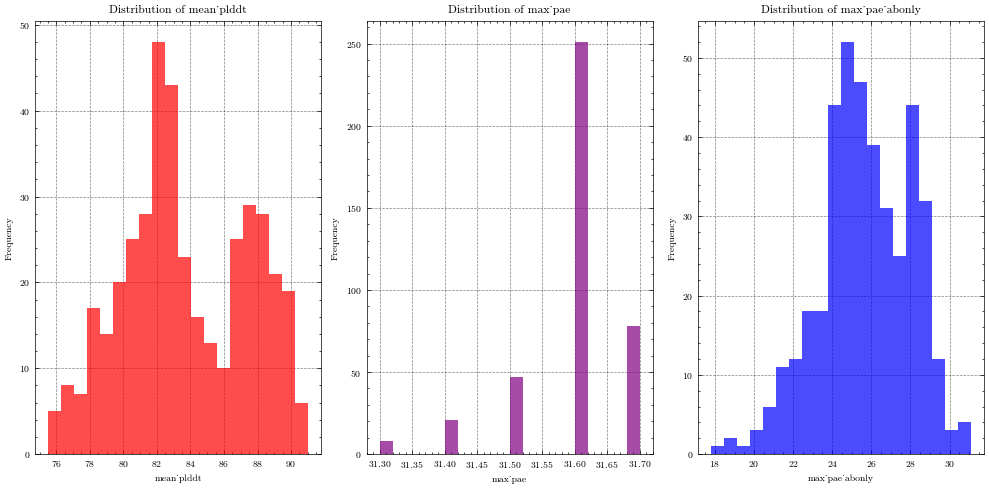

In [108]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))

ax1.hist(df_confidence_summary['mean_plddt'], bins=20, color='red', alpha=0.7)
ax1.set_title('Distribution of mean_plddt')
ax1.set_xlabel('mean_plddt')
ax1.set_ylabel('Frequency')

ax2.hist(df_confidence_summary['max_pae'], bins=20, color='purple', alpha=0.7)
ax2.set_title('Distribution of max_pae')
ax2.set_xlabel('max_pae')
ax2.set_ylabel('Frequency')

ax3.hist(df_confidence_summary['max_pae_abonly'], bins=20, color='blue', alpha=0.7)
ax3.set_title('Distribution of max_pae_abonly')
ax3.set_xlabel('max_pae_abonly')
ax3.set_ylabel('Frequency')

# ax3.hist(df_confidence_summary['ptm'], bins=20, color='blue', alpha=0.7)
# ax3.set_title('Distribution of ptm')
# ax3.set_xlabel('ptm')
# ax3.set_ylabel('Frequency')

# ax4.hist(df_confidence_summary['iptm'], bins=20, color='green', alpha=0.7)
# ax4.set_title('Distribution of iptm')
# ax4.set_xlabel('iptm')
# ax4.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

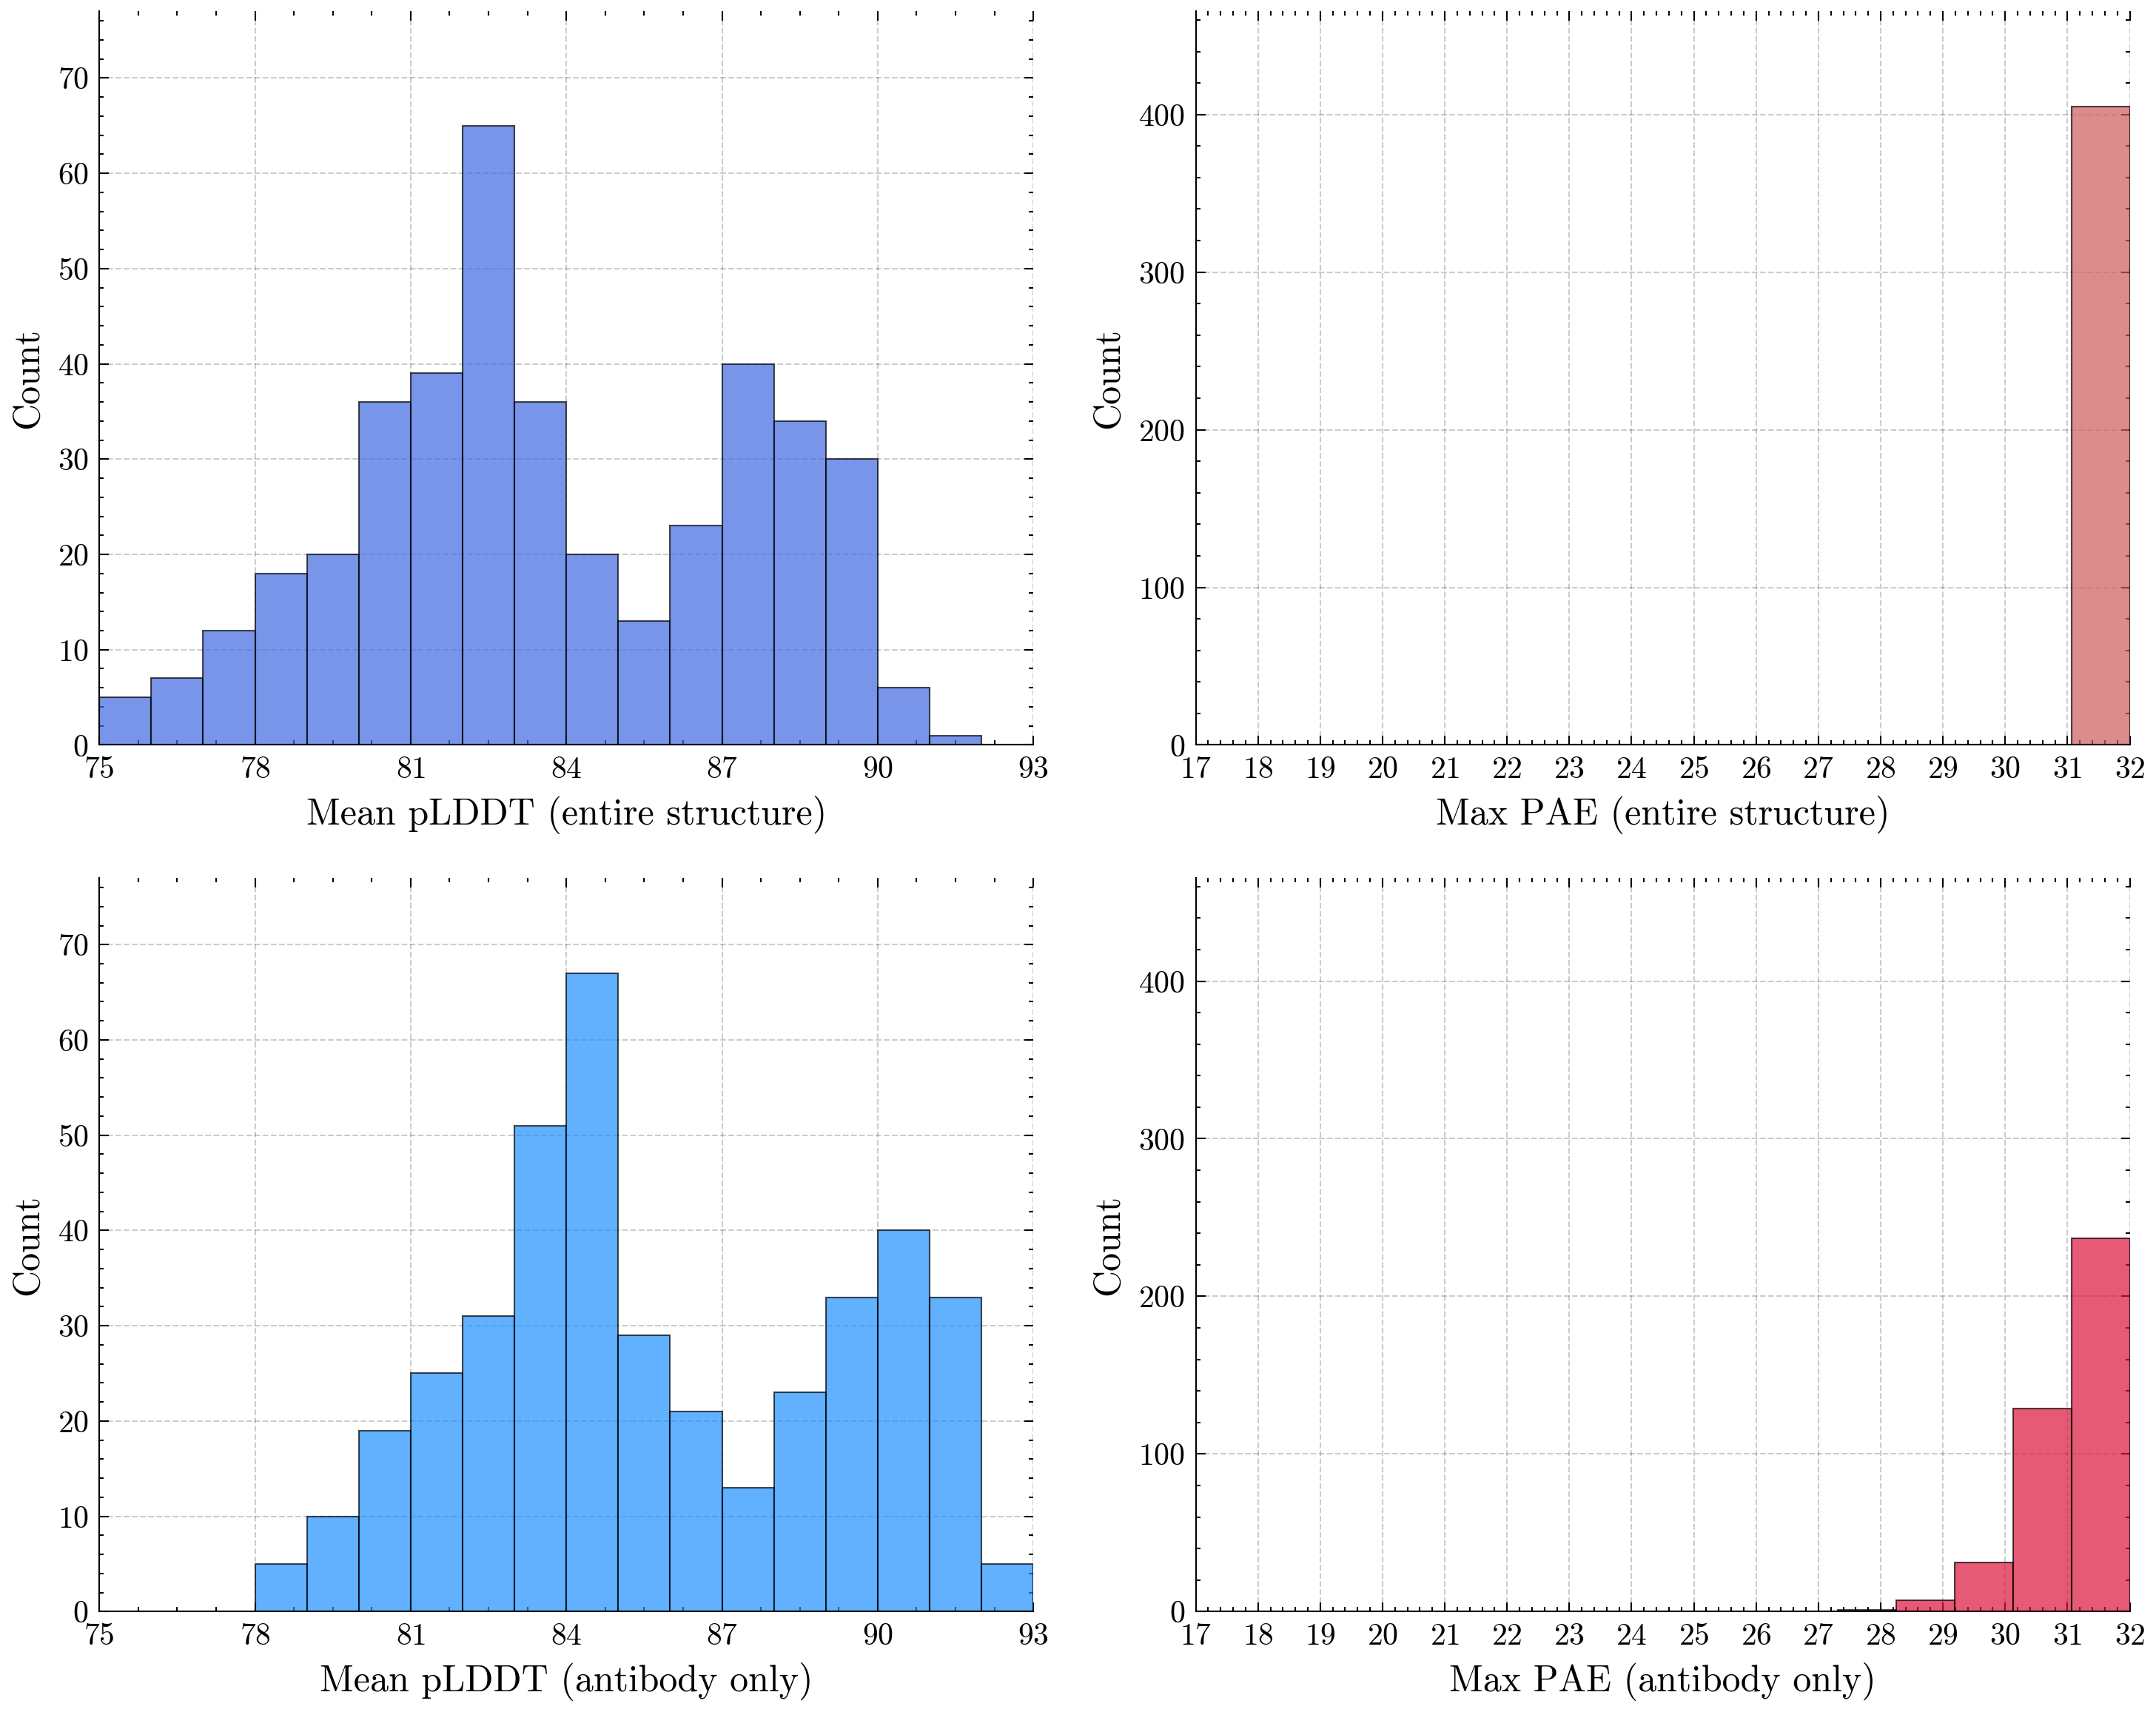

In [163]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# Set style
plt.style.use(['science', 'nature', 'no-latex'])

# Create figure with correct panel organization
fig = plt.figure(figsize=(10, 8), dpi=300)
gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, 0])  # Top-left: mean pLDDT (entire)
ax2 = fig.add_subplot(gs[0, 1])  # Top-right: max PAE (entire)
ax3 = fig.add_subplot(gs[1, 0])  # Bottom-left: mean pLDDT (antibody-only)
ax4 = fig.add_subplot(gs[1, 1])  # Bottom-right: max PAE (antibody-only)

# --- Configure bins and ranges ---
# pLDDT range 75-93
plddt_bins = np.linspace(75, 93, 19)  # 18 bins
plddt_ticks = np.arange(75, 94, 3)    # Ticks every 3 units

# PAE range 28-32
pae_bins = np.linspace(17, 32, 17)    # 16 bins
pae_ticks = np.arange(17, 33, 1)      # Ticks every 1 unit

# --- Calculate maximum frequencies ---
plddt_max = max(
    np.histogram(df_confidence_summary['mean_plddt'], bins=plddt_bins)[0].max(),
    np.histogram(df_confidence_summary['mean_plddt_abonly'], bins=plddt_bins)[0].max()
) * 1.15

pae_max = max(
    np.histogram(df_confidence_summary['max_pae'], bins=pae_bins)[0].max(),
    np.histogram(df_confidence_summary['max_pae_abonly'], bins=pae_bins)[0].max()
) * 1.15

# --- Plot 1: mean pLDDT (entire) ---
ax1.hist(df_confidence_summary['mean_plddt'], 
         bins=plddt_bins, color='royalblue', alpha=0.7, 
         edgecolor='k', linewidth=0.5)
ax1.set(xlabel='Mean pLDDT (entire structure)', 
        ylabel='Count',
        xlim=(75, 93),
        ylim=(0, plddt_max),
        xticks=plddt_ticks)

# --- Plot 2: max PAE (entire) ---
ax2.hist(df_confidence_summary['max_pae'], 
         bins=pae_bins, color='indianred', alpha=0.7,
         edgecolor='k', linewidth=0.5)
ax2.set(xlabel='Max PAE (entire structure)',
        ylabel='Count',
        ylim=(0, pae_max),
        xlim=(17, 32),
        xticks=pae_ticks)

# --- Plot 3: mean pLDDT (antibody-only) ---
ax3.hist(df_confidence_summary['mean_plddt_abonly'], 
         bins=plddt_bins, color='dodgerblue', alpha=0.7,
         edgecolor='k', linewidth=0.5)
ax3.set(xlabel='Mean pLDDT (antibody only)',
        ylabel='Count',
        xlim=(75, 93),
        ylim=(0, plddt_max),
        xticks=plddt_ticks)

# --- Plot 4: max PAE (antibody-only) ---
ax4.hist(df_confidence_summary['max_pae_abonly'], 
         bins=pae_bins, color='crimson', alpha=0.7,
         edgecolor='k', linewidth=0.5)
ax4.set(xlabel='Max PAE (antibody only)',
        ylabel='Count',
        xlim=(17, 32),
        ylim=(0, pae_max),
        xticks=pae_ticks)

# --- Consistent styling ---
for ax in [ax1, ax2, ax3, ax4]:
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel(ax.get_xlabel(), fontsize=12) 
    ax.set_ylabel(ax.get_ylabel(), fontsize=12)

plt.tight_layout(pad=2.0)
plt.show()

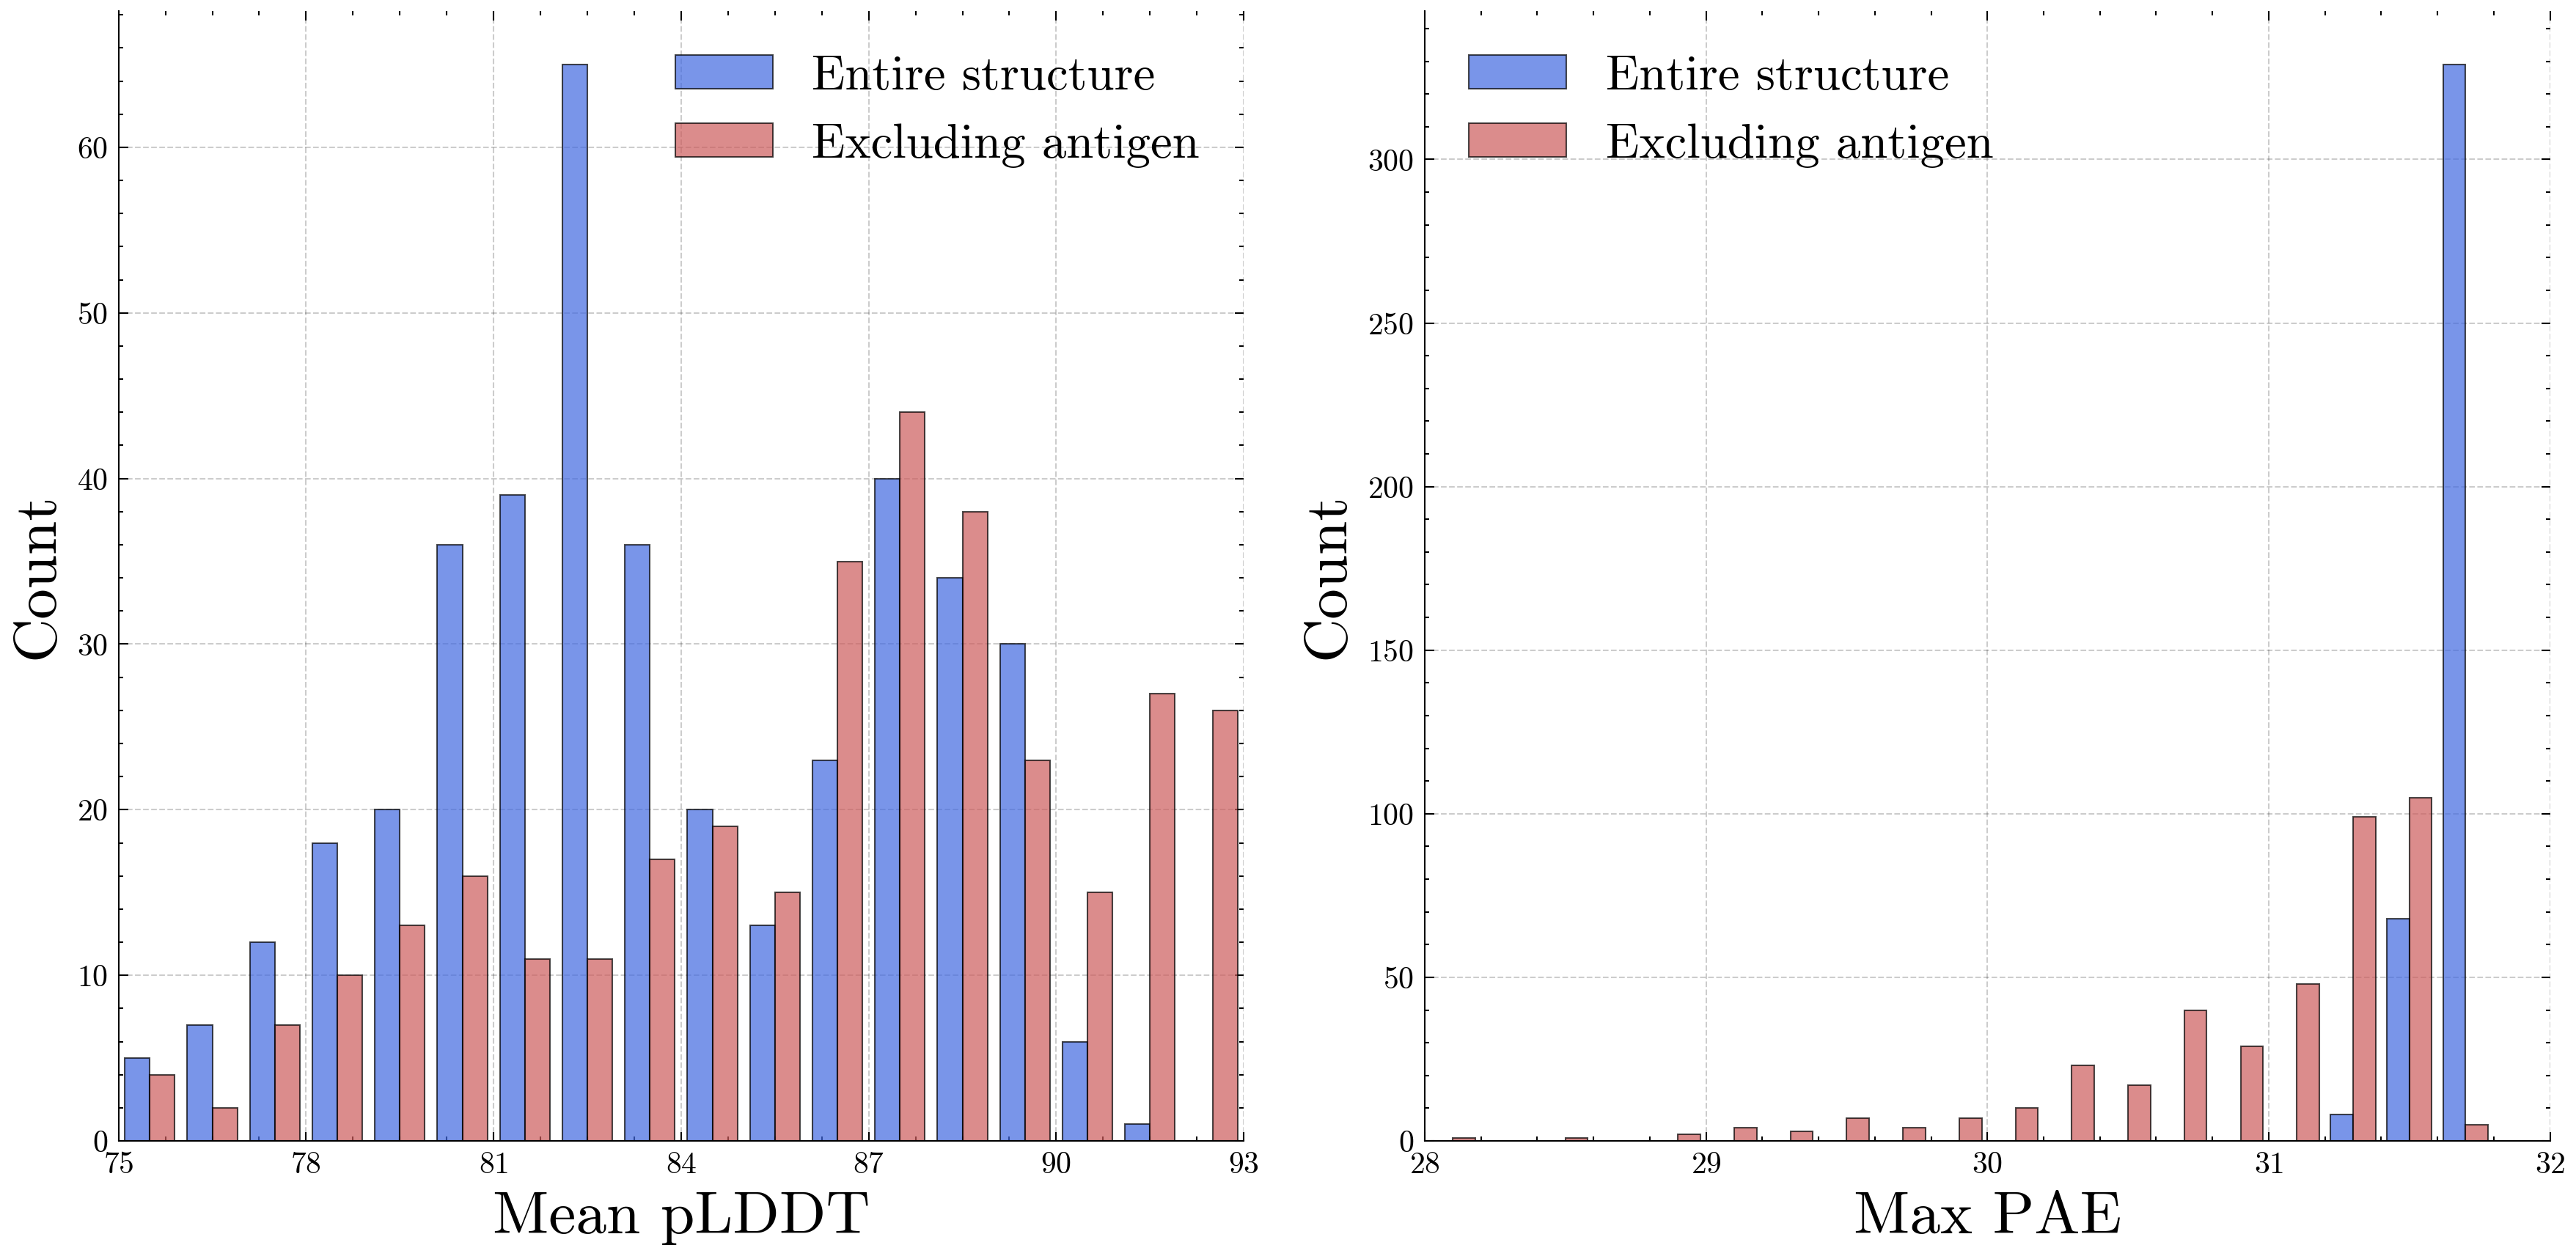

In [193]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# Set style
plt.style.use(['science', 'nature', 'no-latex'])

fontsize = 20
legendsize=16

# Create figure with two panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# --- Configure bins and ranges ---
# pLDDT range
plddt_bins = np.linspace(75, 93, 19)
plddt_ticks = np.arange(75, 94, 3)

# PAE range 
pae_bins = np.linspace(28, 32, 21)
pae_ticks = np.arange(28, 33, 1)
# pae_bins = np.linspace(17, 32, 21)
# pae_ticks = np.arange(17, 33, 1)

# --- Plot 1: Combined pLDDT (entire + antibody-only) ---
ax1.hist([df_confidence_summary['mean_plddt'], df_confidence_summary['mean_plddt_abonly']],
         bins=plddt_bins, 
         color=['royalblue', 'indianred'], 
         alpha=0.7,
         edgecolor='k', 
         linewidth=0.5,
         label=['Entire structure', 'Excluding antigen'])

ax1.set(xlabel='Mean pLDDT',
        ylabel='Count',
        xlim=(75, 93),
        xticks=plddt_ticks)
ax1.legend(fontsize=legendsize, frameon=False)

# --- Plot 2: Combined PAE (entire + antibody-only) ---
ax2.hist([df_confidence_summary['max_pae'], df_confidence_summary['max_pae_abonly']],
         bins=pae_bins,
         color=['royalblue', 'indianred'],
         alpha=0.7,
         edgecolor='k',
         linewidth=0.5,
         label=['Entire structure', 'Excluding antigen'])
# ax2.hist([df_confidence_summary['max_pae'], df_confidence_summary['max_pae_abonly'], df_confidence_summary['max_pae_ababonly']],
#          bins=pae_bins,
#          color=['royalblue', 'indianred', 'purple'],
#          alpha=0.7,
#          edgecolor='k',
#          linewidth=0.5,
#          label=['Entire structure', 'Excluding antigen'])

ax2.set(xlabel='Max PAE',
        ylabel='Count',
        xlim=(28, 32),
        xticks=pae_ticks)
ax2.legend(fontsize=legendsize, frameon=False)

# --- Consistent styling ---
for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel(ax.get_xlabel(), fontsize=fontsize)
    ax.set_ylabel(ax.get_ylabel(), fontsize=fontsize)

plt.tight_layout(pad=2.0)
plt.show()

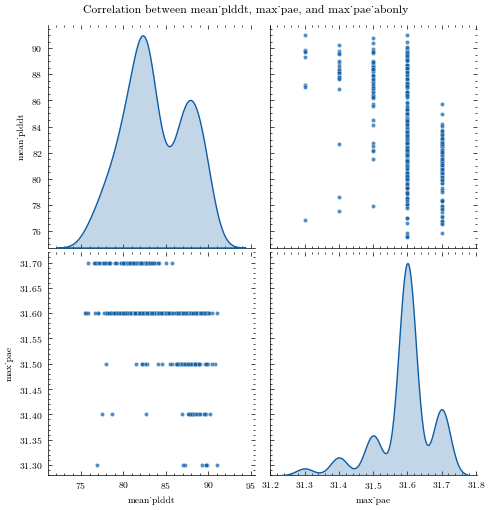

In [70]:
import seaborn as sns

import matplotlib.pyplot as plt

# Select the columns of interest
columns_of_interest = ['mean_plddt', 'max_pae']
df_correlation = df_confidence_summary[columns_of_interest]

# Create a pairplot to visualize the correlation
sns.pairplot(df_correlation, kind='scatter', diag_kind='kde', plot_kws={'alpha': 0.7})
plt.suptitle('Correlation between mean_plddt, max_pae, and max_pae_abonly', y=1.02)
plt.show()

#### Converting to ANTIPASTI pdb input

In [30]:
import pymol2
import os

In [31]:
cif_in_dir = AF_OUTPUT_PATH
pdb_out_dir = STRUCTURES_PATH

# List all folders in the directory
files = [f for f in os.listdir(cif_in_dir) if os.path.isdir(os.path.join(cif_in_dir, f))]

# Print the number of files
print(f"Number of files in {cif_in_dir}: {len(files)}")

Number of files in ../af3/af_output/: 405


In [32]:
# iterate over files in
# that directory
for protein_name in os.listdir(cif_in_dir):
    cifname = os.path.join(cif_in_dir, protein_name, protein_name+'_model.cif')
    if os.path.isfile(cifname):
        print(cifname)
        with pymol2.PyMOL() as pymol:
            pymol.cmd.load(cifname,'myprotein')
            pymol.cmd.save(os.path.join(pdb_out_dir, protein_name+'_af.pdb'), selection='myprotein')

../af3/af_output/1855/1855_model.cif
../af3/af_output/0184/0184_model.cif
../af3/af_output/1852/1852_model.cif
../af3/af_output/0177/0177_model.cif
../af3/af_output/0183/0183_model.cif
../af3/af_output/1890/1890_model.cif
../af3/af_output/1863/1863_model.cif
../af3/af_output/0179/0179_model.cif
../af3/af_output/0522/0522_model.cif
../af3/af_output/1837/1837_model.cif
../af3/af_output/1830/1830_model.cif
../af3/af_output/0788/0788_model.cif
../af3/af_output/0775/0775_model.cif
../af3/af_output/1839/1839_model.cif
../af3/af_output/0781/0781_model.cif
../af3/af_output/0786/0786_model.cif
../af3/af_output/1801/1801_model.cif
../af3/af_output/0178/0178_model.cif
../af3/af_output/1862/1862_model.cif
../af3/af_output/1891/1891_model.cif
../af3/af_output/0176/0176_model.cif
../af3/af_output/1854/1854_model.cif
../af3/af_output/0171/0171_model.cif
../af3/af_output/0185/0185_model.cif
../af3/af_output/0773/0773_model.cif
../af3/af_output/0787/0787_model.cif
../af3/af_output/1800/1800_model.cif
.

In [33]:
# List all files in the directory
files = [f for f in os.listdir(pdb_out_dir)]

# Print the number of files
print(f"Number of files in {pdb_out_dir}: {len(files)}")

Number of files in ../data/structures/: 405
